In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("C:/Users/PC/Downloads/TM-Assignment Twitter/twitter_training.csv", header=None, names=['ID', 'Topic', 'Sentiment', 'Content'])
df_train.head()

,ID,Topic,Sentiment,Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
df_val = pd.read_csv("C:/Users/PC/Downloads/TM-Assignment Twitter/twitter_validation.csv", header=None, names=['ID', 'Topic', 'Sentiment', 'Content'])
df_val.head()

,ID,Topic,Sentiment,Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [4]:
df_train = df_train[df_train['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]
df_val = df_val[df_val['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

In [5]:
print("Missing value - TRAIN Before")
print(df_train.isnull().sum())

print("\nMissing value - VALIDATION Before")
print(df_val.isnull().sum())

# Handle Missing Value
df_train = df_train.dropna(subset=['Content', 'Sentiment']).copy()
df_val = df_val.dropna(subset=['Content', 'Sentiment']).copy()

print("\nMissing value - TRAIN After")
print(df_train.isnull().sum())

print("\nMissing value - VALIDATION After")
print(df_val.isnull().sum())

Missing value - TRAIN Before
ID             0
Topic          0
Sentiment      0
Content      571
dtype: int64

Missing value - VALIDATION Before
ID           0
Topic        0
Sentiment    0
Content      0
dtype: int64

Missing value - TRAIN After
ID           0
Topic        0
Sentiment    0
Content      0
dtype: int64

Missing value - VALIDATION After
ID           0
Topic        0
Sentiment    0
Content      0
dtype: int64


# **EDA**

In [6]:
print("Distribusi TRAIN:")
print(df_train['Sentiment'].value_counts())

print("\nPersentase TRAIN:")
print((df_train['Sentiment'].value_counts(normalize=True) * 100).round(2))

print("\nDistribusi VALIDATION:")
print(df_val['Sentiment'].value_counts())

print("\nPersentase VALIDATION:")
print((df_val['Sentiment'].value_counts(normalize=True) * 100).round(2))

Distribusi TRAIN:
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

Persentase TRAIN:
Sentiment
Negative    36.58
Positive    33.79
Neutral     29.63
Name: proportion, dtype: float64

Distribusi VALIDATION:
Sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64

Persentase VALIDATION:
Sentiment
Neutral     34.42
Positive    33.45
Negative    32.13
Name: proportion, dtype: float64


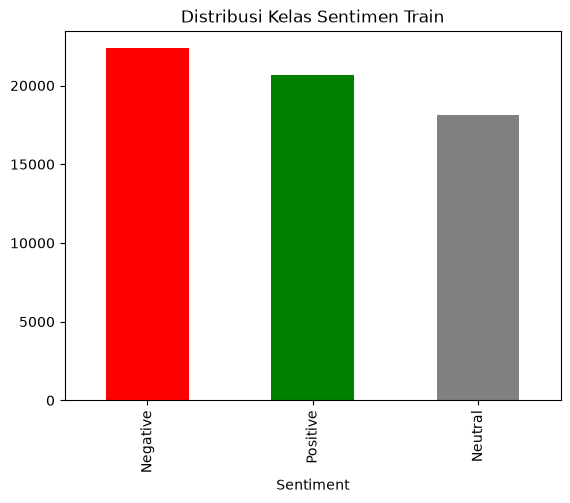

In [7]:
df_train['Sentiment'].value_counts().plot(kind='bar', color=['red', 'green', 'gray', 'blue'])
plt.title('Distribusi Kelas Sentimen Train')
plt.show()

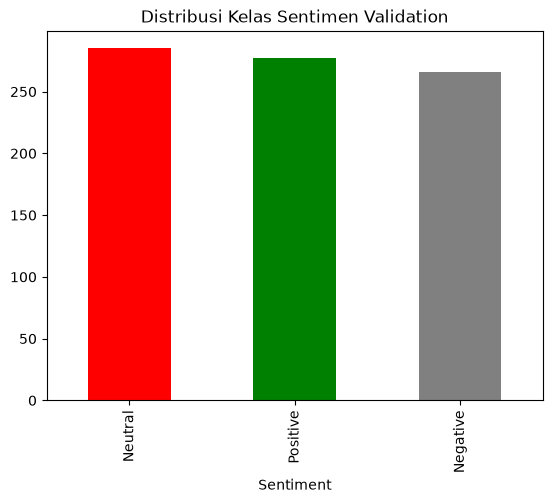

In [8]:
df_val['Sentiment'].value_counts().plot(kind='bar', color=['red', 'green', 'gray', 'blue'])
plt.title('Distribusi Kelas Sentimen Validation')
plt.show()

In [9]:
# RAW TEXT

from collections import Counter
import re

all_text = ' '.join(df_train['Content'].astype(str)).lower()

words_raw = re.findall(r'\b[a-zA-Z]+\b', all_text)

freq_raw = Counter(words_raw)

print("Top 20 Raw Words:")
print(freq_raw.most_common(20))

Top 20 Raw Words:
[('the', 36587), ('i', 30588), ('to', 24104), ('and', 21996), ('a', 19510), ('of', 15858), ('it', 15252), ('is', 14734), ('in', 12918), ('for', 12678), ('this', 12063), ('you', 10110), ('my', 9987), ('on', 9912), ('t', 9824), ('s', 9370), ('that', 9099), ('com', 8159), ('game', 7443), ('with', 7287)]


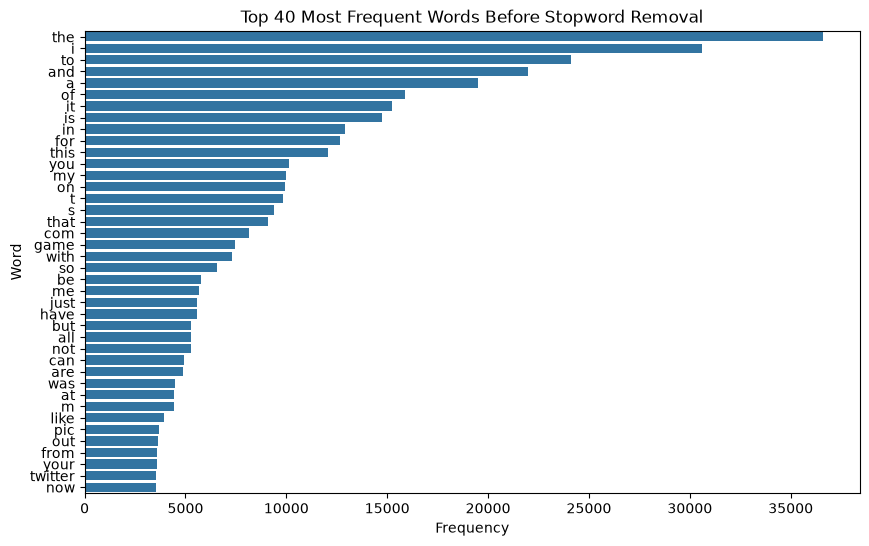

In [10]:
top_words = freq_raw.most_common(40)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title('Top 40 Most Frequent Words Before Stopword Removal')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

In [11]:
# STOPWORD REMOVAL

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

words_clean = [
    word for word in words_raw
    if word not in ENGLISH_STOP_WORDS
]

freq_clean = Counter(words_clean)

print("Top 20 Words Setelah Stopword Removal:")
print(freq_clean.most_common(20))

Top 20 Words Setelah Stopword Removal:
[('t', 9824), ('s', 9370), ('com', 8159), ('game', 7443), ('just', 5568), ('m', 4416), ('like', 3921), ('pic', 3679), ('twitter', 3559), ('play', 3086), ('johnson', 3043), ('good', 2903), ('new', 2899), ('really', 2723), ('love', 2593), ('time', 2568), ('unk', 2487), ('shit', 2314), ('amazon', 2204), ('people', 2157)]


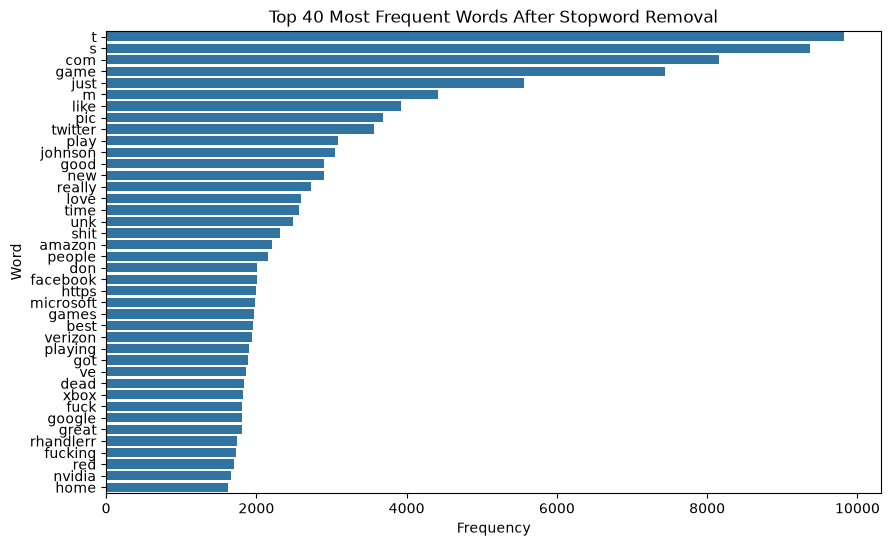

In [12]:
top_words = freq_clean.most_common(40)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title('Top 40 Most Frequent Words After Stopword Removal')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

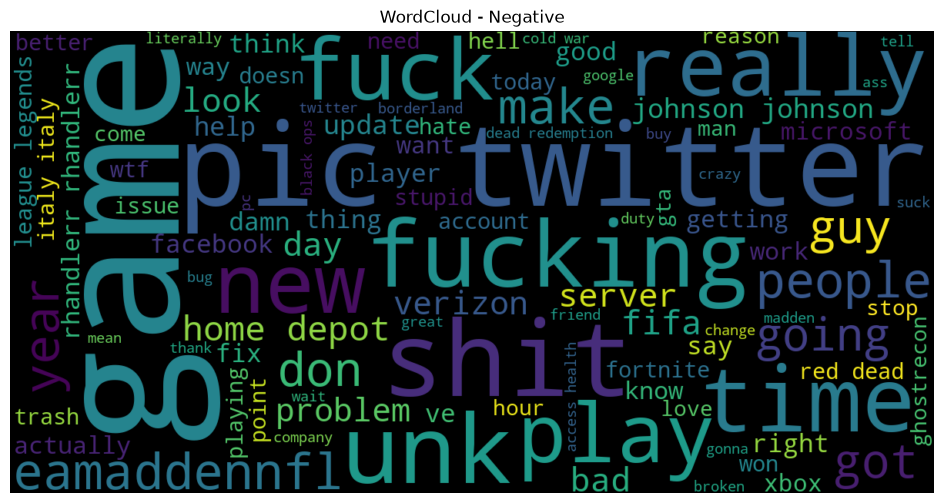

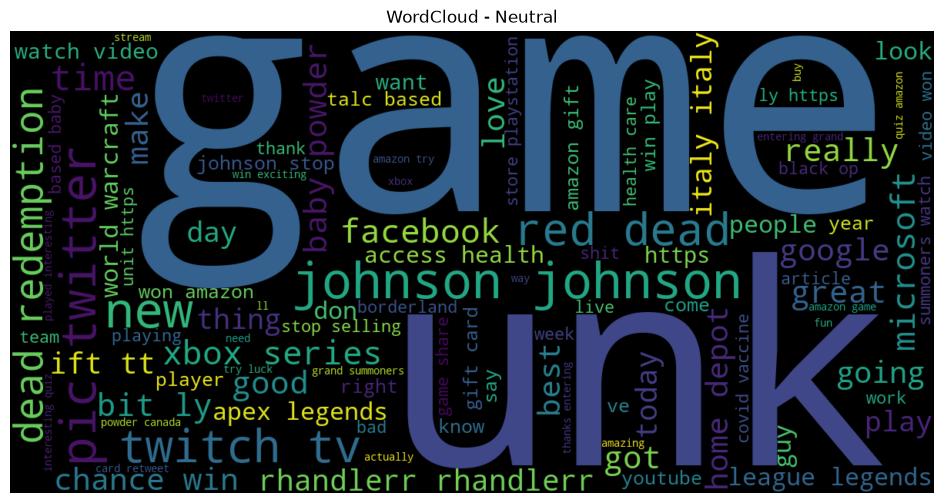

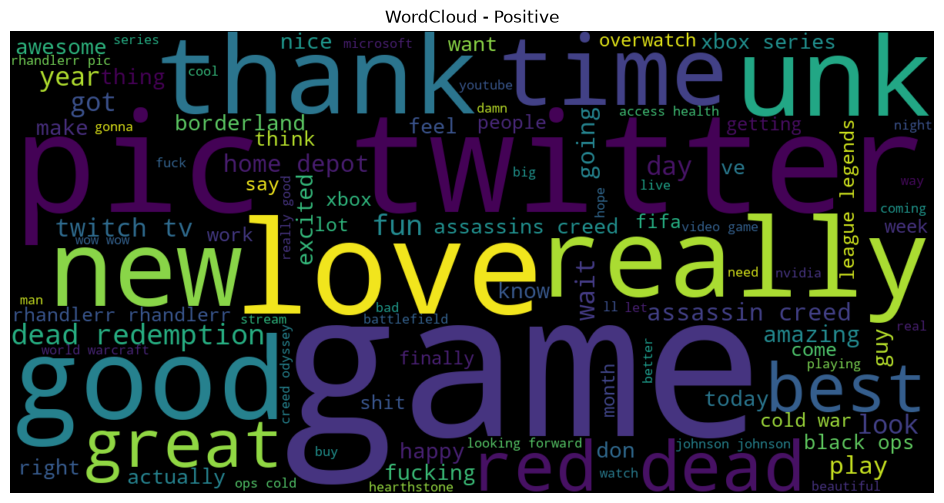

In [13]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
import matplotlib.pyplot as plt

for sentiment in ['Negative', 'Neutral', 'Positive']:
    
    # Ambil teks berdasarkan sentiment
    text = ' '.join(
        df_train.loc[df_train['Sentiment'] == sentiment, 'Content']
        .astype(str)
    ).lower()

    # Ambil kata
    words = re.findall(r'\b[a-zA-Z]{2,}\b', text)

    # Hapus stopwords
    words = [
        word for word in words
        if word not in ENGLISH_STOP_WORDS
    ]

    clean_text = ' '.join(words)

    # WordCloud
    wc = WordCloud(
        width=1200,
        height=600,
        background_color='black',
        max_words=100
    ).generate(clean_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud - {sentiment}')
    plt.axis('off')
    plt.show()

## **PREPROCESSING**

In [14]:
# CEK CONTENT
url_count = df_train['Content'].astype(str).str.contains(
    r'https?://\S+|www\.\S+|\b(?:[\w-]+\.)+[a-zA-Z]{2,}(?:/\S*)?',
    regex=True,
    case=False,
    na=False
).sum()

mention_count = df_train['Content'].astype(str).str.contains(
    r'@\w+',
    regex=True,
    na=False
).sum()

unk_count = df_train['Content'].astype(str).str.contains(
    r'<unk>|\[UNK\]',
    regex=True,
    case=False,
    na=False
).sum()

print("Jumlah teks mengandung URL     :", url_count)
print("Jumlah teks mengandung mention :", mention_count)
print("Jumlah teks mengandung <unk>   :", unk_count)

Jumlah teks mengandung URL     : 13085
Jumlah teks mengandung mention : 9868
Jumlah teks mengandung <unk>   : 2264


In [15]:
def clean_text(text):
    text = str(text)

    # Hapus <unk> dan [UNK]
    text = re.sub(
        r'<unk>|\[UNK\]',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # Hapus URL
    text = re.sub(
        r'https?://\S+|www\.\S+|\b(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}(?:/\S*)?',
        ' ',
        text
    )

    # Hapus mention
    text = re.sub(
        r'@\w+',
        ' ',
        text
    )

    # Rapikan whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [16]:
df_train['Clean_Content'] = df_train['Content'].apply(clean_text)
df_val['Clean_Content'] = df_val['Content'].apply(clean_text)

In [17]:
pd.set_option('display.max_colwidth', None)

contoh_cleaning = df_train[
    df_train['Content'].astype(str).str.contains(
        r'https?://\S+|www\.\S+|@\w+|<unk>|\[UNK\]',
        regex=True,
        case=False,
        na=False
    )
][['Content', 'Clean_Content', 'Sentiment']].head(20)

display(contoh_cleaning)

,Content,Clean_Content,Sentiment
6,So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg,So I spent a few hours making something for fun. . . If you don't know I am a HUGE fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy!,Positive
30,WE FINISHED BORDERLANDS 3 FINALLY YAS! Thank you for hanging out everyone! It was fun. I will try to stream tomorrow but if not I might so some IRL streams while awayu. We shall see. Thank you so much for the raids @mompou_mumpow @MegaMagwitch and @KfdMitch.,WE FINISHED BORDERLANDS 3 FINALLY YAS! Thank you for hanging out everyone! It was fun. I will try to stream tomorrow but if not I might so some IRL streams while awayu. We shall see. Thank you so much for the raids and .,Positive
33,WE FINISHED BORDERLANDS 3 UPDATE YAS! Thank you for hanging out guys! It was fun. I will try to stream and even if not I might so some IRL streams while awayu. We shall go. Thank you so much for the raids @mompou_mumpow @MegaMagwitch and Hope.,WE FINISHED BORDERLANDS 3 UPDATE YAS! Thank you for hanging out guys! It was fun. I will try to stream and even if not I might so some IRL streams while awayu. We shall go. Thank you so much for the raids and Hope.,Positive
34,WE FINISHED BORDERLANDS 3 AND FINALLY YAS! Thank you everyone for hanging out everyone! It was fun. I will try to make stream tomorrow but if not I might make so some IRL streams while awayu. 10 We never shall see. Thank you both so... much for the raids @mompou_mumpow or @MegaMagwitch and 4 @KfdMitch.,WE FINISHED BORDERLANDS 3 AND FINALLY YAS! Thank you everyone for hanging out everyone! It was fun. I will try to make stream tomorrow but if not I might make so some IRL streams while awayu. 10 We never shall see. Thank you both so... much for the raids or and 4 .,Positive
35,WE FINISHED BORDERLANDS 3 FINALLY YAS! Hey you for hanging out so! It was fun. I will try that stream tomorrow and if not I might use some IRL streams from awayu. We shall see. Thank you so much how many raids @mompou_mumpow did and their.,WE FINISHED BORDERLANDS 3 FINALLY YAS! Hey you for hanging out so! It was fun. I will try that stream tomorrow and if not I might use some IRL streams from awayu. We shall see. Thank you so much how many raids did and their.,Positive
41,<unk> Gearbox really time to fix this 10 drops in the new Borderlands 3 DLC or be fine to force bosses on Mayhem 10 to get a legendary drop while everyone else i get 6-10 drops.. Really needs alot,Gearbox really time to fix this 10 drops in the new Borderlands 3 DLC or be fine to force bosses on Mayhem 10 to get a legendary drop while everyone else i get 6-10 drops.. Really needs alot,Negative
47,Check<unk> this epic streamer!.,Check this epic streamer!.,Neutral
57,why does like<unk> man in borderlands have slicked back hair or you heard of bangs you stupid assholes,why does like man in borderlands have slicked back hair or you heard of bangs you stupid assholes,Negative
78,"One of our own @ProfZeroo is live w/ @borderlands 3‼. . . . Catch him here: buff.ly/2WmmiP5 . . Say ""Streamer Shouts"" in chat for a chance to be in a coming. @streamer_shouts Shout Out. . .","One of our own is live w/ 3‼. . . . Catch him here: . . Say ""Streamer Shouts"" in chat for a chance to be in a coming. Shout Out. . .",Neutral
81,"One of our own @ProfZeroo is live >/ @borderlands 3‼. . !. Catch him here: buff.ly/2WmmiP5 p. Say some Shouts"" in chat – a chance to be in a coming. Also Shout Out...","One of our own is live >/ 3‼. . !. Catch him here: p. Say some Shouts"" in chat – a chance to be in a coming. Also Shout Out...",Neutral


In [18]:
remaining_url = df_train['Clean_Content'].str.contains(
    r'https?://\S+|www\.\S+|\b(?:[\w-]+\.)+[a-zA-Z]{2,}(?:/\S*)?',
    regex=True,
    case=False,
    na=False
).sum()

remaining_mention = df_train['Clean_Content'].str.contains(
    r'@\w+',
    regex=True,
    case=False,
    na=False
).sum()

remaining_unk = df_train['Clean_Content'].str.contains(
    r'<unk>|\[UNK\]',
    regex=True,
    case=False,
    na=False
).sum()

print("Sisa URL     :", remaining_url)
print("Sisa mention :", remaining_mention)
print("Sisa <unk>   :", remaining_unk)

Sisa URL     : 0
Sisa mention : 0
Sisa <unk>   : 0


In [19]:
# REMOVE EMPTY TEXT
df_train = df_train[
    df_train['Clean_Content'].str.strip() != ''
].copy()

df_val = df_val[
    df_val['Clean_Content'].str.strip() != ''
].copy()

In [20]:
print("Jumlah data TRAIN     :", len(df_train))
print("Jumlah data VALIDATION:", len(df_val))

print("\nMissing value TRAIN:")
print(df_train[['Content', 'Clean_Content', 'Sentiment']].isnull().sum())

print("\nMissing value VALIDATION:")
print(df_val[['Content', 'Clean_Content', 'Sentiment']].isnull().sum())

print("\nEmpty Clean_Content TRAIN:",
      (df_train['Clean_Content'].str.strip() == '').sum())

print("Empty Clean_Content VALIDATION:",
      (df_val['Clean_Content'].str.strip() == '').sum())

Jumlah data TRAIN     : 60823
Jumlah data VALIDATION: 828

Missing value TRAIN:
Content          0
Clean_Content    0
Sentiment        0
dtype: int64

Missing value VALIDATION:
Content          0
Clean_Content    0
Sentiment        0
dtype: int64

Empty Clean_Content TRAIN: 0
Empty Clean_Content VALIDATION: 0


In [21]:
# Cari Clean_Content yang punya kata sama lebih dari 1 label

# Train Data
conflict = (
    df_train.groupby('Clean_Content')['Sentiment']
    .nunique()
)

conflict = conflict[conflict > 1]

print("Train conflict:", len(conflict))

# Buang semua Clean_Content yang labelnya conflict
df_train = df_train[
    ~df_train['Clean_Content'].isin(conflict.index)
].copy()

# Baru deduplicate
df_train = (
    df_train
    .dropna(subset=['Clean_Content', 'Sentiment'])
    .drop_duplicates(subset='Clean_Content', keep='first')
)

# Validation Data
val_conflict = (
    df_val.groupby('Clean_Content')['Sentiment']
    .nunique()
)

val_conflict = val_conflict[val_conflict > 1]

print("Validation conflict:", len(val_conflict))

# Buang conflict
df_val = df_val[
    ~df_val['Clean_Content'].isin(val_conflict.index)
].copy()

Train conflict: 116
Validation conflict: 0


In [22]:
# CEK OVERLAP TRAIN VALIDATION
train_content = set(df_train['Clean_Content'])
val_content = set(df_val['Clean_Content'])

overlap = train_content.intersection(val_content)

print("Jumlah overlap train-validation:", len(overlap))

Jumlah overlap train-validation: 430


In [23]:
df_train = df_train[
    ~df_train['Clean_Content'].isin(overlap)
].copy()

print("Jumlah data TRAIN setelah menghapus overlap:", len(df_train))

Jumlah data TRAIN setelah menghapus overlap: 56176


In [24]:
overlap_check = set(df_train['Clean_Content']).intersection(
    set(df_val['Clean_Content'])
)

print("Overlap setelah cleaning:", len(overlap_check))

Overlap setelah cleaning: 0


In [25]:
print("Missing value - TRAIN")
print(df_train.isnull().sum())

print("\nMissing value - VALIDATION")
print(df_val.isnull().sum())

print("\nJumlah duplikat TRAIN:", df_train.duplicated().sum())
print("Jumlah duplikat VAL:", df_val.duplicated().sum())

Missing value - TRAIN
ID               0
Topic            0
Sentiment        0
Content          0
Clean_Content    0
dtype: int64

Missing value - VALIDATION
ID               0
Topic            0
Sentiment        0
Content          0
Clean_Content    0
dtype: int64

Jumlah duplikat TRAIN: 0
Jumlah duplikat VAL: 0


In [26]:
print("TRAIN:")
print(df_train['Sentiment'].value_counts())

print("\nPersentase TRAIN:")
print(
    (df_train['Sentiment'].value_counts(normalize=True) * 100).round(2)
)

print("\nVALIDATION:")
print(df_val['Sentiment'].value_counts())

print("\nPersentase VALIDATION:")
print(
    (df_val['Sentiment'].value_counts(normalize=True) * 100).round(2)
)

TRAIN:
Sentiment
Negative    20821
Positive    18694
Neutral     16661
Name: count, dtype: int64

Persentase TRAIN:
Sentiment
Negative    37.06
Positive    33.28
Neutral     29.66
Name: proportion, dtype: float64

VALIDATION:
Sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64

Persentase VALIDATION:
Sentiment
Neutral     34.42
Positive    33.45
Negative    32.13
Name: proportion, dtype: float64


# **DATA SPLITTING**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_dev, y_train, y_dev = train_test_split(
    df_train['Clean_Content'],
    df_train['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_train['Sentiment']
)

print("Train :", len(X_train))
print("Dev   :", len(X_dev))
print("Val   :", len(df_val))

Train : 44940
Dev   : 11236
Val   : 828


# **FEATURE EXTRACTION**

## Term Frequency–Inverse Document Frequency (TF-IDF).

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF N-GRAM 1-2
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_dev_tfidf = tfidf.transform(X_dev)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Dev TF-IDF shape  :", X_dev_tfidf.shape)

Train TF-IDF shape: (44940, 118256)
Dev TF-IDF shape  : (11236, 118256)


# **BASELINE MODEL**

In [29]:
# FOKUS PENGUKURAN METRIK
from sklearn.metrics import make_scorer, recall_score

negative_recall = make_scorer(
    recall_score,
    labels=['Negative'],
    average='macro'
)

## LINEAR SVC

In [30]:
from sklearn.svm import LinearSVC

svc_model = LinearSVC(
    C=1.0
)

svc_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [31]:
y_dev_pred = svc_model.predict(X_dev_tfidf)
print(y_dev_pred[:20])

['Neutral' 'Negative' 'Negative' 'Negative' 'Neutral' 'Negative' 'Neutral'
 'Negative' 'Negative' 'Positive' 'Neutral' 'Positive' 'Positive'
 'Neutral' 'Neutral' 'Negative' 'Positive' 'Neutral' 'Negative' 'Negative']


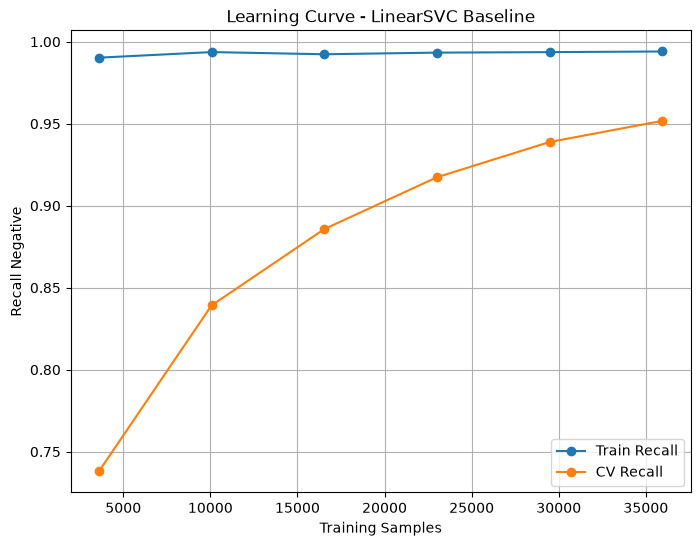

,Training Samples,Train Recall,CV Recall,Gap
0,3595,0.990286,0.737933,0.252354
1,10066,0.993702,0.839217,0.154486
2,16537,0.992372,0.885746,0.106626
3,23009,0.993369,0.917387,0.075982
4,29480,0.993672,0.938881,0.054791
5,35952,0.994056,0.951789,0.042267


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, recall_score

svc_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('svc', LinearSVC(C=1))
])

train_sizes_svc, train_scores_svc, val_scores_svc = learning_curve(
    svc_baseline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring=negative_recall,
    n_jobs=2
)

train_mean_svc = train_scores_svc.mean(axis=1)
val_mean_svc = val_scores_svc.mean(axis=1)
gap_svc = train_mean_svc - val_mean_svc

plt.figure(figsize=(8, 6))
plt.plot(
    train_sizes_svc,
    train_mean_svc,
    marker='o',
    label='Train Recall'
)
plt.plot(
    train_sizes_svc,
    val_mean_svc,
    marker='o',
    label='CV Recall'
)

plt.xlabel('Training Samples')
plt.ylabel('Recall Negative')
plt.title('Learning Curve - LinearSVC Baseline')
plt.legend()
plt.grid()
plt.show()

gap_table_svc = pd.DataFrame({
    'Training Samples': train_sizes_svc,
    'Train Recall': train_mean_svc,
    'CV Recall': val_mean_svc,
    'Gap': gap_svc
})

display(gap_table_svc)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_dev,
    y_dev_pred,
    digits=4
))

              precision    recall  f1-score   support

    Negative     0.9541    0.9640    0.9590      4165
     Neutral     0.9535    0.9418    0.9476      3332
    Positive     0.9497    0.9492    0.9494      3739

    accuracy                         0.9525     11236
   macro avg     0.9524    0.9516    0.9520     11236
weighted avg     0.9525    0.9525    0.9525     11236



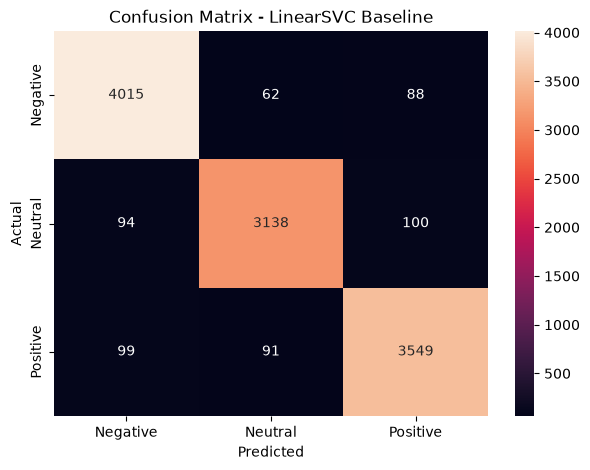

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_base_svc = confusion_matrix(
    y_dev,
    y_dev_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_base_svc,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LinearSVC Baseline')
plt.show()

## LOGISTIC REGRESSION

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [36]:
y_dev_pred_lr = lr_model.predict(X_dev_tfidf)

print(y_dev_pred_lr[:20])

['Neutral' 'Negative' 'Negative' 'Negative' 'Neutral' 'Negative' 'Neutral'
 'Positive' 'Negative' 'Positive' 'Neutral' 'Positive' 'Positive'
 'Neutral' 'Neutral' 'Positive' 'Positive' 'Neutral' 'Positive' 'Negative']


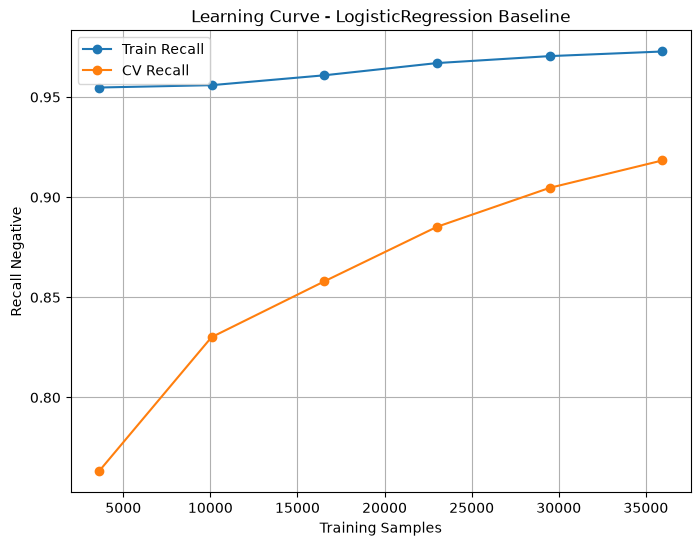

,Training Samples,Train Recall,CV Recall,Gap
0,3595,0.954757,0.763029,0.191728
1,10066,0.955927,0.830091,0.125836
2,16537,0.960853,0.857949,0.102905
3,23009,0.966963,0.885206,0.081757
4,29480,0.970439,0.904659,0.065780
5,35952,0.972743,0.918348,0.054395


In [37]:
lr_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('logreg', LogisticRegression(
        C=1,
        max_iter=1000
    ))
])

train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    lr_baseline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring=negative_recall,
    n_jobs=2
)

train_mean_lr = train_scores_lr.mean(axis=1)
val_mean_lr = val_scores_lr.mean(axis=1)
gap_lr = train_mean_lr - val_mean_lr

plt.figure(figsize=(8, 6))
plt.plot(
    train_sizes_lr,
    train_mean_lr,
    marker='o',
    label='Train Recall'
)
plt.plot(
    train_sizes_lr,
    val_mean_lr,
    marker='o',
    label='CV Recall'
)

plt.xlabel('Training Samples')
plt.ylabel('Recall Negative')
plt.title('Learning Curve - LogisticRegression Baseline')
plt.legend()
plt.grid()
plt.show()

gap_table_lr = pd.DataFrame({
    'Training Samples': train_sizes_lr,
    'Train Recall': train_mean_lr,
    'CV Recall': val_mean_lr,
    'Gap': gap_lr
})

display(gap_table_lr)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_dev,
    y_dev_pred_lr,
    digits=4
))

              precision    recall  f1-score   support

    Negative     0.8986    0.9323    0.9152      4165
     Neutral     0.9117    0.8643    0.8874      3332
    Positive     0.9034    0.9075    0.9054      3739

    accuracy                         0.9039     11236
   macro avg     0.9046    0.9014    0.9026     11236
weighted avg     0.9041    0.9039    0.9037     11236



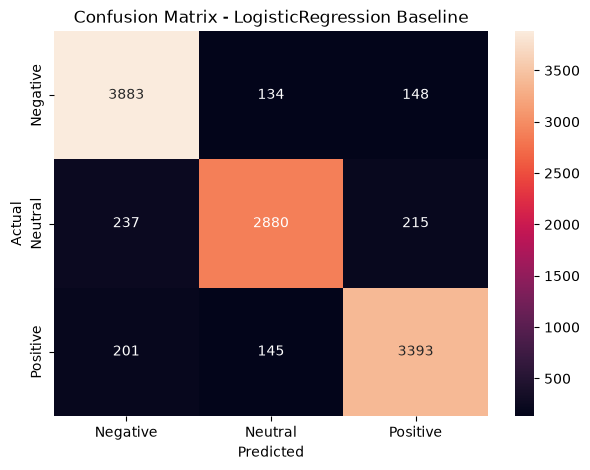

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_base_lr = confusion_matrix(
    y_dev,
    y_dev_pred_lr,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_base_lr,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LogisticRegression Baseline')
plt.show()

# **TUNE MODEL**

## TUNE LINEAR SVC

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

negative_recall = make_scorer(
    recall_score,
    labels=['Negative'],
    average='macro'
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svc', LinearSVC())
])
# Best Parameters:
# {'svc__C': 10, 'svc__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}
param_grid_svc = {
    'tfidf__ngram_range': [(1,3)],
    'tfidf__min_df': [1],
    'tfidf__max_df': [0.50],
    'tfidf__sublinear_tf': [True],
    'svc__C': [10],
    'svc__class_weight': [None]
}

grid_search_svc = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_svc,
    scoring=negative_recall,
    cv=5,
    n_jobs=2,
    verbose=2
)

grid_search_svc.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVC())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [10], 'svc__class_weight': [None], 'tfidf__max_df': [0.5], 'tfidf__min_df': [1], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(r...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples

In [41]:
# param_grid_svc = {
#     'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
#     'tfidf__min_df': [1, 2, 3, 5],
#     'tfidf__max_df': [0.50, 0.70, 0.80, 0.90, 0.95, 1.00],
#     'tfidf__sublinear_tf': [False, True],
#     'svc__C': [0.1, 0.5, 1, 2, 5, 10],
#     'svc__class_weight': [None, 'balanced']
# }

In [42]:
print("Best Parameters:")
print(grid_search_svc.best_params_)

print("\nBest Negative Recall (CV):")
print(grid_search_svc.best_score_)

Best Parameters:
{'svc__C': 10, 'svc__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}

Best Negative Recall (CV):
0.9635566505197095


In [43]:
# Best Parameters:
# {'svc__C': 5, 'svc__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}

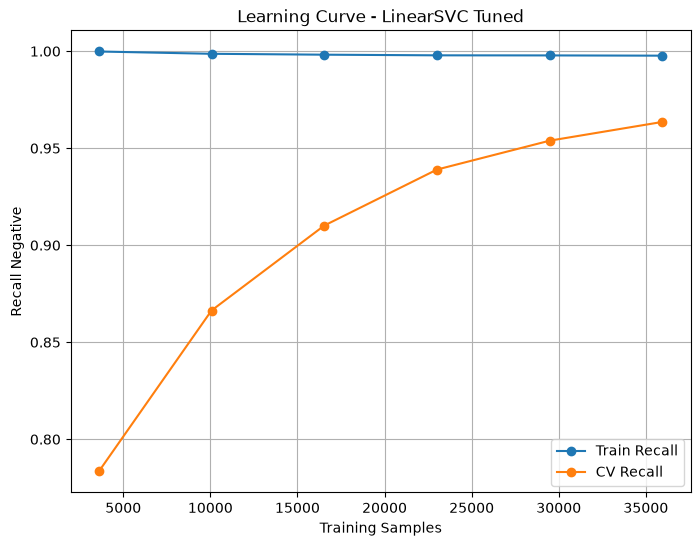

,Training Samples,Train Recall,CV Recall,Gap
0,3595,0.999852,0.783382,0.216470
1,10066,0.998667,0.866354,0.132312
2,16537,0.998207,0.910122,0.088085
3,23009,0.997875,0.939001,0.058874
4,29480,0.997830,0.953891,0.043939
5,35952,0.997704,0.963557,0.034147


In [44]:
svc_tuned = grid_search_svc.best_estimator_

train_sizes_svc_tuned, train_scores_svc_tuned, val_scores_svc_tuned = learning_curve(
    svc_tuned,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring=negative_recall,
    n_jobs=2
)

train_mean_svc_tuned = train_scores_svc_tuned.mean(axis=1)
val_mean_svc_tuned = val_scores_svc_tuned.mean(axis=1)
gap_svc_tuned = train_mean_svc_tuned - val_mean_svc_tuned

plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes_svc_tuned,
    train_mean_svc_tuned,
    marker='o',
    label='Train Recall'
)

plt.plot(
    train_sizes_svc_tuned,
    val_mean_svc_tuned,
    marker='o',
    label='CV Recall'
)

plt.xlabel('Training Samples')
plt.ylabel('Recall Negative')
plt.title('Learning Curve - LinearSVC Tuned')
plt.legend()
plt.grid()
plt.show()

gap_table_svc_tuned = pd.DataFrame({
    'Training Samples': train_sizes_svc_tuned,
    'Train Recall': train_mean_svc_tuned,
    'CV Recall': val_mean_svc_tuned,
    'Gap': gap_svc_tuned
})

display(gap_table_svc_tuned)

In [45]:
best_model_svc = grid_search_svc.best_estimator_

y_dev_pred_grid = best_model_svc.predict(X_dev)

print(classification_report(
    y_dev,
    y_dev_pred_grid,
    digits=4
))

              precision    recall  f1-score   support

    Negative     0.9584    0.9690    0.9637      4165
     Neutral     0.9594    0.9514    0.9554      3332
    Positive     0.9618    0.9572    0.9595      3739

    accuracy                         0.9599     11236
   macro avg     0.9599    0.9592    0.9595     11236
weighted avg     0.9599    0.9599    0.9598     11236



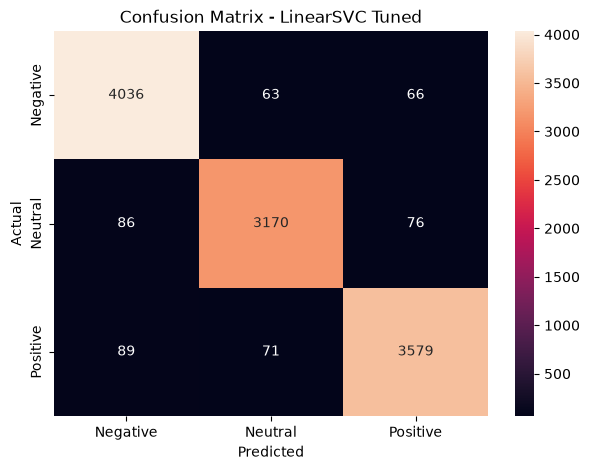

In [46]:
from sklearn.metrics import confusion_matrix

cm_tune_svc = confusion_matrix(
    y_dev,
    y_dev_pred_grid,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tune_svc,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LinearSVC Tuned')

plt.show()

## TUNE LOGISTIC REGRESSION

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(max_iter=1000))
])
# Best Parameters:
# {'lr__C': 10, 'lr__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}
param_grid_lr = {
    'tfidf__ngram_range': [(1,3)],
    'tfidf__min_df': [1],
    'tfidf__max_df': [0.50],
    'tfidf__sublinear_tf': [True],
    'lr__C': [10],
    'lr__class_weight': [None]
}

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring=negative_recall,
    cv=5,
    n_jobs=2,
    verbose=2
)

grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [10], 'lr__class_weight': [None], 'tfidf__max_df': [0.5], 'tfidf__min_df': [1], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(r...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_m

In [48]:
# param_grid_lr = {
#     'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
#     'tfidf__min_df': [1, 2, 3, 5],
#     'tfidf__max_df': [0.50, 0.70, 0.80, 0.90, 0.95, 1.00],
#     'tfidf__sublinear_tf': [False, True],
#     'lr__C': [0.1, 0.5, 1, 2, 5, 10],
#     'lr__class_weight': [None, 'balanced']
# }

In [49]:
print("Best Parameters:")
print(grid_search_lr.best_params_)

print("\nBest Negative Recall (CV):")
print(grid_search_lr.best_score_)

Best Parameters:
{'lr__C': 10, 'lr__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}

Best Negative Recall (CV):
0.9538904964567635


In [50]:
# Best Parameters:
# {'lr__C': 10, 'lr__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}

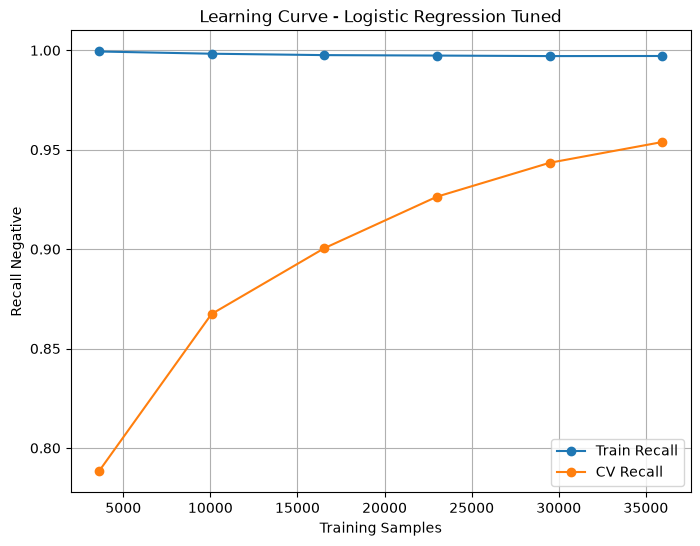

,Training Samples,Train Recall,CV Recall,Gap
0,3595,0.999408,0.788185,0.211223
1,10066,0.998294,0.867375,0.130919
2,16537,0.997588,0.900456,0.097132
3,23009,0.997361,0.926393,0.070968
4,29480,0.997100,0.943444,0.053656
5,35952,0.997148,0.953890,0.043258


In [51]:
lr_tuned = grid_search_lr.best_estimator_

train_sizes_lr_tuned, train_scores_lr_tuned, val_scores_lr_tuned = learning_curve(
    lr_tuned,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring=negative_recall,
    n_jobs=2
)

train_mean_lr_tuned = train_scores_lr_tuned.mean(axis=1)
val_mean_lr_tuned = val_scores_lr_tuned.mean(axis=1)
gap_lr_tuned = train_mean_lr_tuned - val_mean_lr_tuned

plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes_lr_tuned,
    train_mean_lr_tuned,
    marker='o',
    label='Train Recall'
)

plt.plot(
    train_sizes_lr_tuned,
    val_mean_lr_tuned,
    marker='o',
    label='CV Recall'
)

plt.xlabel('Training Samples')
plt.ylabel('Recall Negative')
plt.title('Learning Curve - Logistic Regression Tuned')
plt.legend()
plt.grid()
plt.show()

gap_table_lr_tuned = pd.DataFrame({
    'Training Samples': train_sizes_lr_tuned,
    'Train Recall': train_mean_lr_tuned,
    'CV Recall': val_mean_lr_tuned,
    'Gap': gap_lr_tuned
})

display(gap_table_lr_tuned)

In [52]:
best_model_lr = grid_search_lr.best_estimator_

y_dev_pred_grid = best_model_lr.predict(X_dev)

print(classification_report(
    y_dev,
    y_dev_pred_grid,
    digits=4
))

              precision    recall  f1-score   support

    Negative     0.9420    0.9592    0.9505      4165
     Neutral     0.9490    0.9280    0.9384      3332
    Positive     0.9462    0.9457    0.9460      3739

    accuracy                         0.9454     11236
   macro avg     0.9458    0.9443    0.9450     11236
weighted avg     0.9455    0.9454    0.9454     11236



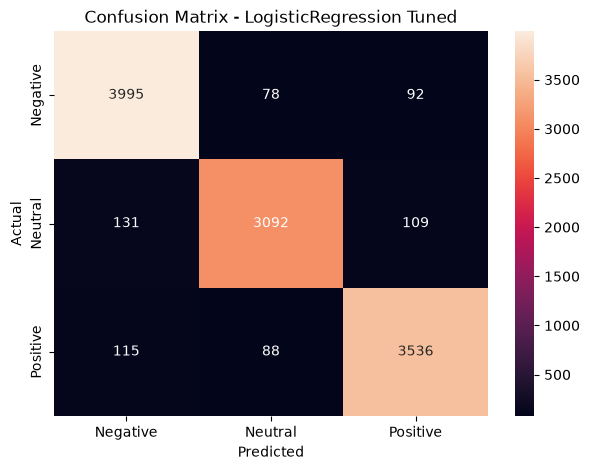

In [53]:
cm_tune_lr = confusion_matrix(
    y_dev,
    y_dev_pred_grid,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tune_lr,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LogisticRegression Tuned')

plt.show()

# **COMPARISON TUNE MODEL**

In [54]:
pred_svc = best_model_svc.predict(X_dev)
pred_lr = best_model_lr.predict(X_dev)

recall_svc = recall_score(
    y_dev,
    pred_svc,
    labels=['Negative'],
    average='macro'
)

recall_lr = recall_score(
    y_dev,
    pred_lr,
    labels=['Negative'],
    average='macro'
)

comparison = pd.DataFrame({
    'Model': [
        'LinearSVC Tuned',
        'Logistic Regression Tuned'
    ],
    'Recall Negative': [
        recall_svc,
        recall_lr
    ]
})

display(
    comparison.sort_values(
        'Recall Negative',
        ascending=False
    )
)

,Model,Recall Negative
0,LinearSVC Tuned,0.969028
1,Logistic Regression Tuned,0.959184


# **FINAL TEST MODEL (TUNED SVC)**

In [55]:
X_full = pd.concat([X_train, X_dev])
y_full = pd.concat([y_train, y_dev])

print("Jumlah data final training:", len(X_full))
print("Jumlah data final test:", len(df_val))

Jumlah data final training: 56176
Jumlah data final test: 828


In [56]:
# Best Parameters:
# {'svc__C': 10, 'svc__class_weight': None, 'tfidf__max_df': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}

In [57]:
final_model_svc = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=1,
        max_df=0.5,
        sublinear_tf=True
    )),
    ('svc', LinearSVC(
        C=5,
        class_weight=None
    ))
])

final_model_svc.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.5
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [58]:
y_test_pred = final_model_svc.predict(
    df_val['Clean_Content']
)

In [59]:
print("=== FINAL TEST - LINEAR SVC ===")

print(classification_report(
    df_val['Sentiment'],
    y_test_pred,
    digits=4
))

=== FINAL TEST - LINEAR SVC ===
              precision    recall  f1-score   support

    Negative     0.9962    0.9850    0.9905       266
     Neutral     0.9894    0.9860    0.9877       285
    Positive     0.9751    0.9892    0.9821       277

    accuracy                         0.9867       828
   macro avg     0.9869    0.9867    0.9868       828
weighted avg     0.9868    0.9867    0.9867       828



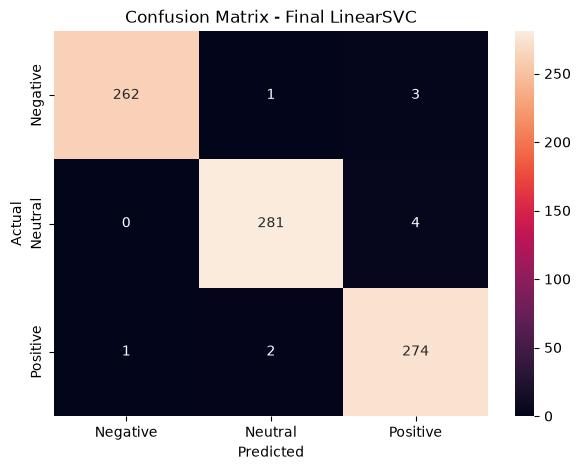

In [60]:
cm_final = confusion_matrix(
    df_val['Sentiment'],
    y_test_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final LinearSVC')

plt.show()

In [61]:
hasil_test = pd.DataFrame({
    'Content': df_val['Content'].values,
    'Actual': df_val['Sentiment'].values,
    'Predicted': y_test_pred
})

hasil_test['Result'] = (
    hasil_test['Actual'] == hasil_test['Predicted']
)

display(
    hasil_test.sample(
        100,
        random_state=42
    )
)

,Content,Actual,Predicted,Result
608,I actually quite like the design of the ps5. It truly feels like the next generation of a console rather than just being a bulkier box with more power,Positive,Positive,True
457,I can get on the phone with @Verizon but I can't get on the phone with @MD_Labor you have to be kidding me pic.twitter.com/AKEm9uWZ2q,Positive,Positive,True
290,hella good options and i loved all of these games but I gotta go with GTA 4 pic.twitter.com/DCuTj9qa8O,Positive,Positive,True
558,You have no idea how ready I am for this. Give me Twisted Fate! #LegendsOfRuneterra #LeagueOfLegends,Neutral,Neutral,True
168,@NBA2K @2KSupport @LD2K @Beluba can y’all please fix this !!! pic.twitter.com/yTZ3HA6Xtf,Negative,Negative,True
...,...,...,...,...
412,I played this interesting quiz on Amazon - Try your luck for a chance to win exciting rewards amazon.in/game/share/gVU… \n#QuizTimeMorningsWithAmazon,Neutral,Neutral,True
355,Help me win this awesome CS:GO giveaway from Idle-Empire! wn.nr/dmjyt5,Positive,Positive,True
266,"Quick 4k, \n#rainbowsixsiege #rainbowsix #ranked #tomclancy #streamer #stream #mixerfamily #mixerlove #mixer #mixerstreamer #mixerstreamersunite #mixerstream \n\nmixer.com/kn_blunt instagram.com/p/B8xYQEHnNBA/…",Neutral,Neutral,True
527,"With Johnson & Johnson baby powder still being available in some markets, we want to alert you of the damages that these talc-based products may cause. Learn more about J&J's lawsuit. bit.ly/3gnsDna https://t.co/PhzQyI0Cqz",Negative,Negative,True
